In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [37]:
from sklearn.datasets import make_blobs
x, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.70)

In [38]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
df.head(10)


,feature1,feature2
0,-0.915605,-2.989015
1,-0.225363,-3.838735
2,5.608931,-0.979885
3,-8.886195,9.123659
4,-8.286934,9.913979
5,-1.048068,-2.707224
6,4.188329,0.042045
7,-1.249235,-2.777359
8,-9.338430,9.652520
9,7.200045,2.699530


In [39]:
df.shape

(500, 2)

In [40]:

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
print(x_scaled[:5])


[[-0.24034288 -1.01658844]
 [-0.13757739 -1.19593025]
 [ 0.73105159 -0.59254174]
 [-1.42703072  1.53991128]
 [-1.33781079  1.70671608]]


In [41]:

kmeans = KMeans(n_clusters=3)
lables = kmeans.fit_predict(x_scaled)
df["Cluster"] = lables
df.head(10)

,feature1,feature2,Cluster
0,-0.915605,-2.989015,1
1,-0.225363,-3.838735,1
2,5.608931,-0.979885,2
3,-8.886195,9.123659,0
4,-8.286934,9.913979,0
5,-1.048068,-2.707224,1
6,4.188329,0.042045,2
7,-1.249235,-2.777359,1
8,-9.338430,9.652520,0
9,7.200045,2.699530,2


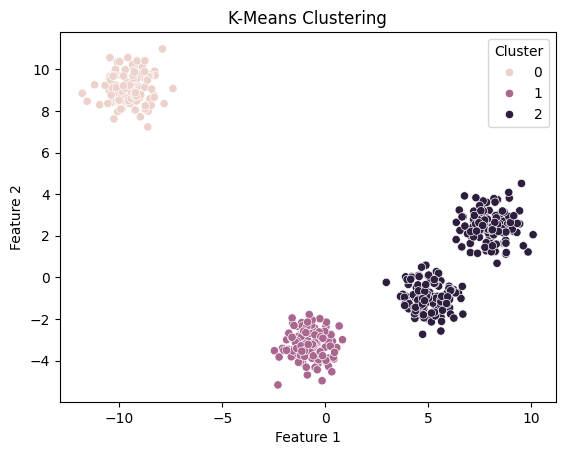

In [42]:

sns.scatterplot(x="feature1", y="feature2", hue="Cluster", data=df)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

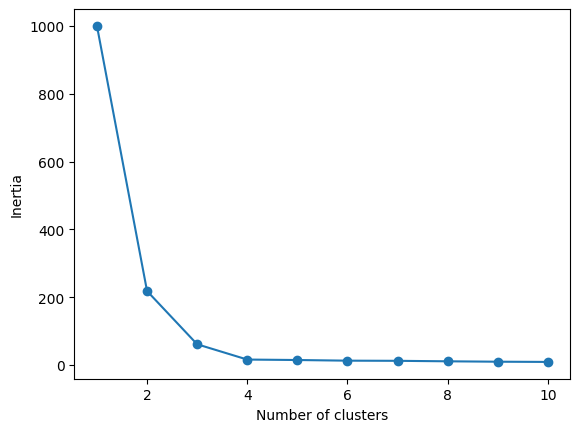

In [43]:
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)
plt.plot(k_value, errors, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [44]:

kmeans = KMeans(n_clusters=4, random_state=42)
df["final_Cluster"] = kmeans.fit_predict(x_scaled)
print(df["final_Cluster"].value_counts())

final_Cluster
3    125
1    125
0    125
2    125
Name: count, dtype: int64


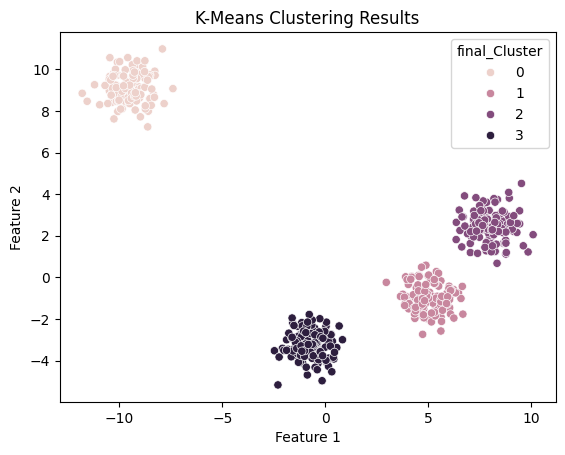

In [45]:
sns.scatterplot(x="feature1", y="feature2", hue="final_Cluster", data=df)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Iris


In [46]:
from sklearn.datasets import load_iris
iris=load_iris()

In [47]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
kmeans=KMeans(n_clusters=3, random_state=42)
df["Cluster"]=kmeans.fit_predict(x_scaled)
print(df["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


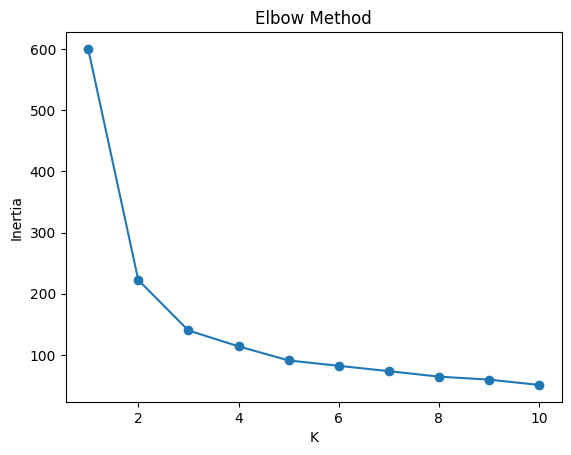

In [48]:
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)

plt.plot(k_value, errors, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["final_Cluster"] = kmeans.fit_predict(x_scaled)
print(df["final_Cluster"].value_counts())


final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000

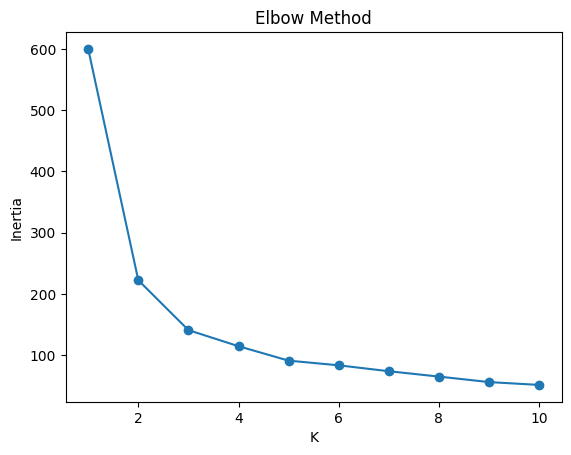

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


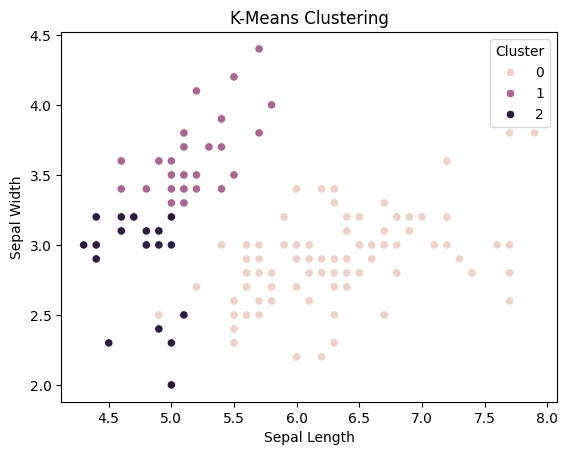

In [50]:
# Load dataset
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)

print(df.head())
print(df.info())
print(df.describe())

# Select numerical features
X = df

#Scalling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)

plt.plot(k_value, errors, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Final Model
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(x_scaled)
print(df["Cluster"].value_counts())

# Visualization
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="Cluster", data=df)
plt.title("K-Means Clustering")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()